<a href="https://www.kaggle.com/code/indrajithsudusinghe/diabetes-prediction-pima-indians-datasete?scriptVersionId=296311299" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diabetes/diabetes.csv


In [2]:
df = pd.read_csv("/kaggle/input/diabetes/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean professional style
sns.set(style="whitegrid")

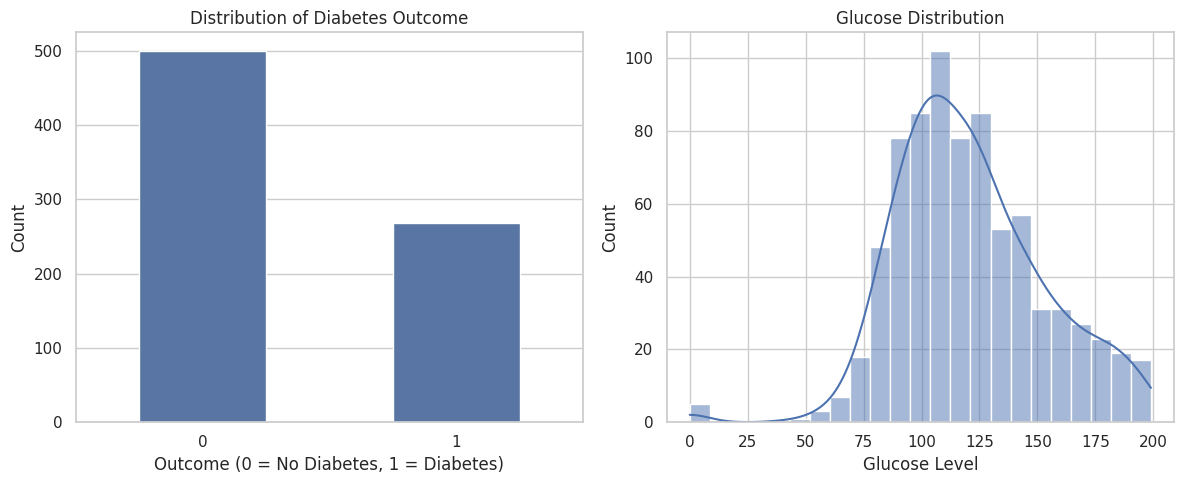

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(x="Outcome", data=df, width=0.5, ax=axes[0])
axes[0].set_title("Distribution of Diabetes Outcome")
axes[0].set_xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
axes[0].set_ylabel("Count")

sns.histplot(df["Glucose"], kde=True, ax=axes[1])
axes[1].set_title("Glucose Distribution")
axes[1].set_xlabel("Glucose Level")

plt.tight_layout()
plt.show()

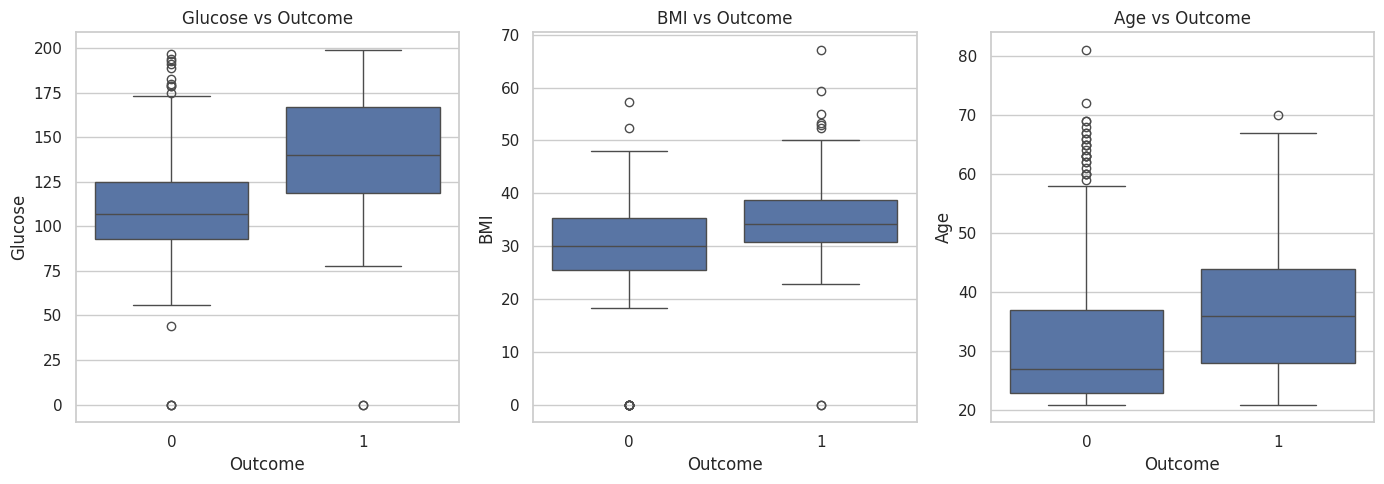

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(x="Outcome", y="Glucose", data=df, ax=axes[0])
axes[0].set_title("Glucose vs Outcome")

sns.boxplot(x="Outcome", y="BMI", data=df, ax=axes[1])
axes[1].set_title("BMI vs Outcome")

sns.boxplot(x="Outcome", y="Age", data=df, ax=axes[2])
axes[2].set_title("Age vs Outcome")

plt.tight_layout()
plt.show()

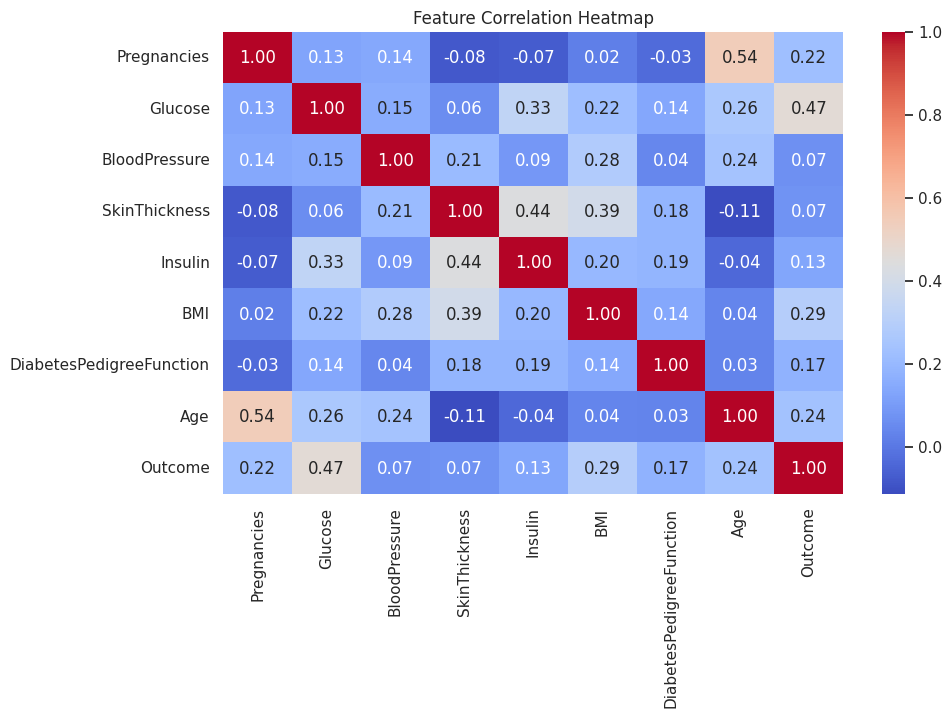

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [10]:
invalid_zero_cols = [
    "Glucose", 
    "BloodPressure", 
    "SkinThickness", 
    "Insulin", 
    "BMI"]

print("Invalid Zero Value Counts (Medically Impossible): \n")

for col in invalid_zero_cols:
    zero_count = (df[col]==0).sum()
    zero_precent = zero_count/len(df)*100          # len(df) = 768 (No of recordings)
    print(f"{col:15s} --> {zero_count:3d} zero ({zero_precent:.2f}%)")
    # 15s = 15 string  
    # 3d =  3 decimal integer

Invalid Zero Value Counts (Medically Impossible): 

Glucose         -->   5 zero (0.65%)
BloodPressure   -->  35 zero (4.56%)
SkinThickness   --> 227 zero (29.56%)
Insulin         --> 374 zero (48.70%)
BMI             -->  11 zero (1.43%)


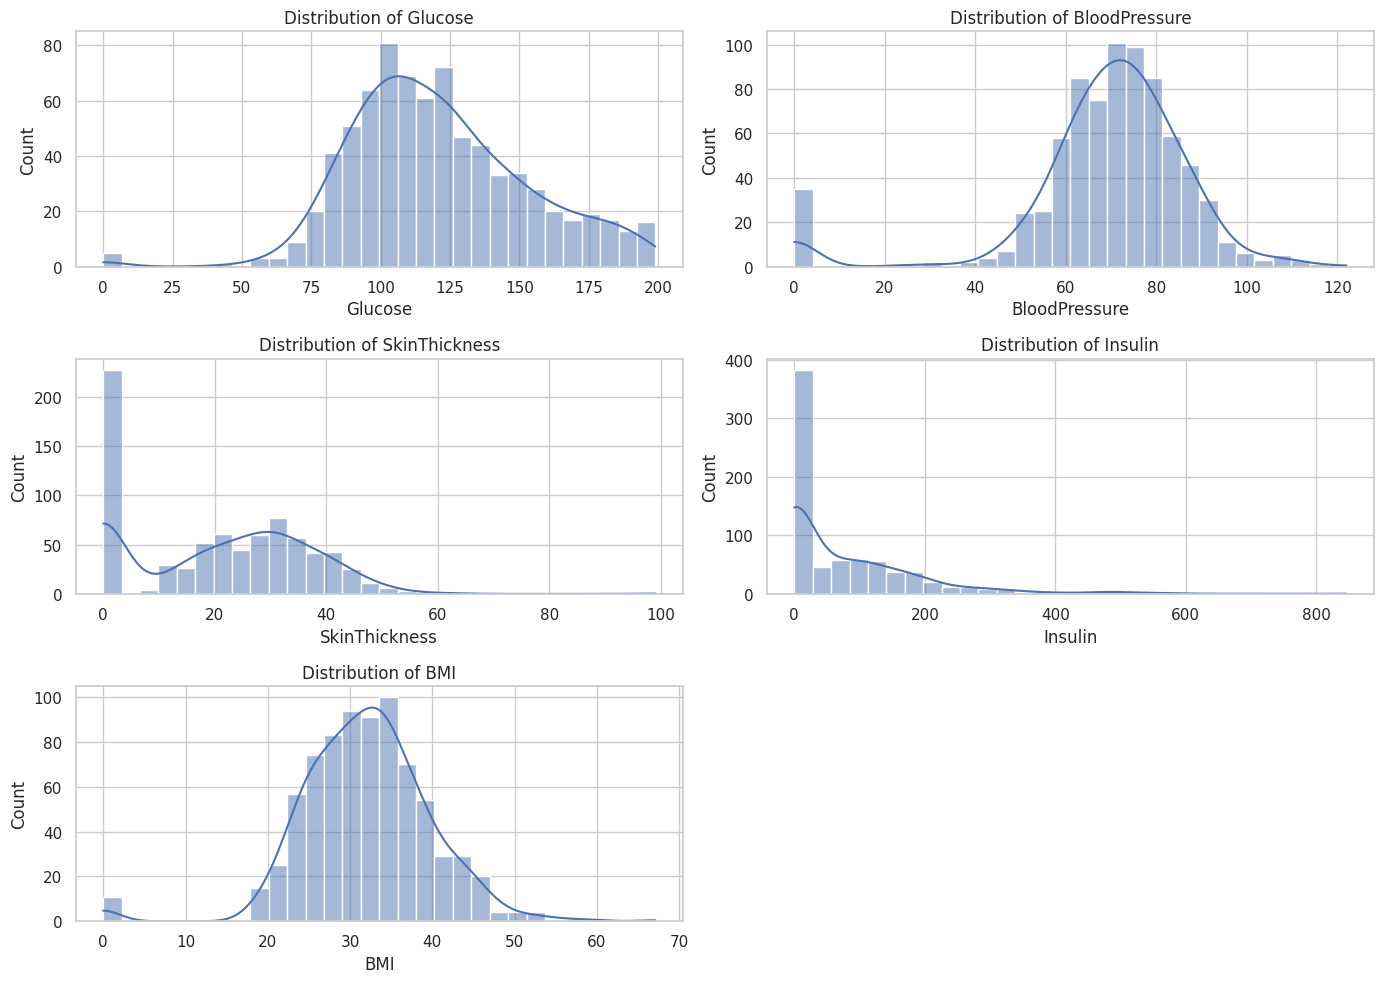

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

for i, col in enumerate(invalid_zero_cols, start=1):  # start from row number = 1 (start=1)
    plt.subplot(3, 2, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [12]:
valid_zero_cols = [
    "Glucose", 
    "BloodPressure", 
    "SkinThickness", 
    "Insulin", 
    "BMI"]

df_clean = df.copy()  # Replace 0 with NaN for selected features

df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

for col in invalid_zero_cols:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

print("Missing value after cleaning")
print(df_clean.isna().sum())

Missing value after cleaning
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [13]:
df_clean[invalid_zero_cols].describe().T   # Transpose (T) = swap rows and columns

,count,mean,std,min,25%,50%,75%,max
Glucose,768.0,121.656250,30.438286,44.0,99.75,117.0,140.25,199.0
BloodPressure,768.0,72.386719,12.096642,24.0,64.00,72.0,80.00,122.0
SkinThickness,768.0,29.108073,8.791221,7.0,25.00,29.0,32.00,99.0
Insulin,768.0,140.671875,86.383060,14.0,121.50,125.0,127.25,846.0
BMI,768.0,32.455208,6.875177,18.2,27.50,32.3,36.60,67.1


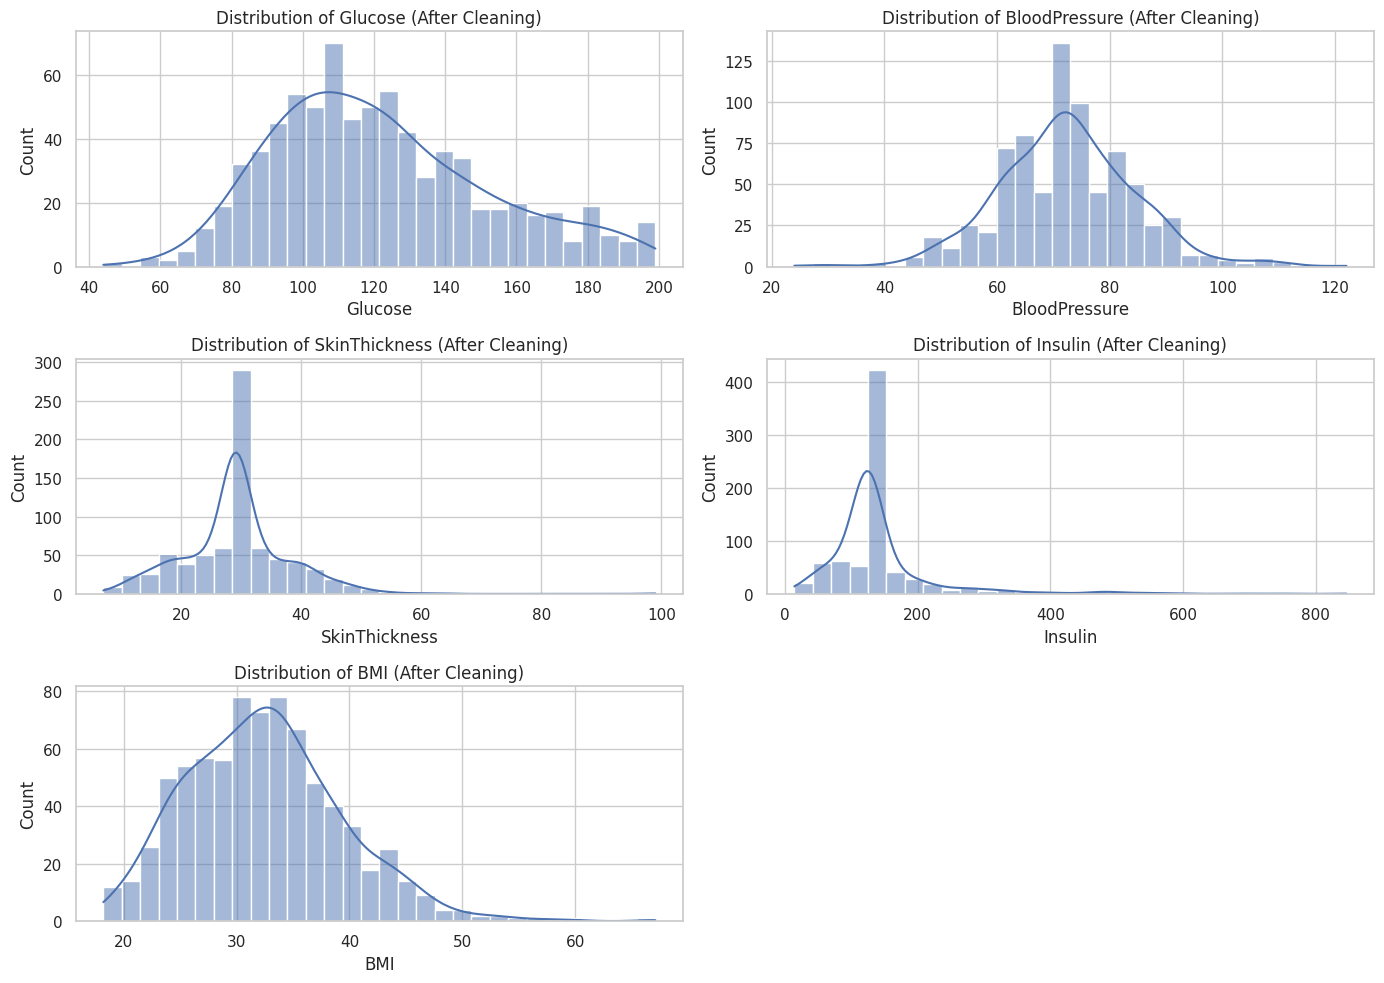

In [14]:
valid_zero_cols = [
    "Glucose", 
    "BloodPressure", 
    "SkinThickness", 
    "Insulin", 
    "BMI"]

plt.figure(figsize=(14,10))

for i, col in enumerate(invalid_zero_cols, start=1):  # start from row number = 1 (start=1)
    plt.subplot(3, 2, i)
    sns.histplot(df_clean[col], bins=30, kde=True)
    plt.title(f"Distribution of {col} (After Cleaning)")

plt.tight_layout()
plt.show()

In [15]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X.shape, y.shape

((768, 8), (768,))

In [16]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [18]:
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.describe().T    

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,-6.476301e-17,1.000652,-1.141852,-0.844885,-0.250952,0.639947,3.906578
Glucose,768.0,4.625929e-18,1.000652,-2.552931,-0.720163,-0.153073,0.611265,2.542658
BloodPressure,768.0,5.782412e-18,1.000652,-4.002619,-0.693761,-0.031990,0.629782,4.104082
SkinThickness,768.0,-1.526557e-16,1.000652,-2.516429,-0.467597,-0.012301,0.329171,7.955377
Insulin,768.0,1.503427e-17,1.000652,-1.467353,-0.222085,-0.181541,-0.155477,8.170442
BMI,768.0,2.613650e-16,1.000652,-2.074783,-0.721209,-0.022590,0.603256,5.042397
DiabetesPedigreeFunction,768.0,2.451743e-16,1.000652,-1.189553,-0.688969,-0.300128,0.466227,5.883565
Age,768.0,1.931325e-16,1.000652,-1.041549,-0.786286,-0.360847,0.660206,4.063716


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y    # Dataset is slightly imbalanced, We want same class ratio in train & test
)                 # with "stratify=y" Very similar percentages in train and test --> Train → ~65% / 35% and  

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape, "\n")

print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))


Training set shape: (614, 8)
Test set shape: (154, 8) 

Train target distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Test target distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


# Logistic Regression - Baseline Model

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000)  # maximum iteration (rounds) is 1000

log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [21]:
y_pred = log_reg.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
}).reset_index(drop=True)

results["Results"] = results["Actual"] == results["Predicted"]
results.head(5)


,Actual,Predicted,Results
0,0,1,False
1,0,0,True
2,0,0,True
3,1,0,False
4,0,0,True


In [22]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))    # accuracy = accuracy_score(y_test, y_pred) and round to 3 decimal

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)


print(f"* Test set shape: {X_test.shape}")
print("Confusion Matrix:\n", cm)


Accuracy: 0.701

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.75      0.81      0.78       100
    Diabetes       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154

* Test set shape: (154, 8)
Confusion Matrix:
 [[81 19]
 [27 27]]


# Logistic Regression - With class_weight="balanced" 

In [23]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

log_reg_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

log_reg_balanced.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [24]:
y_pred_bal = log_reg_balanced.predict(X_test)

results_bal = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_bal
}).reset_index(drop=True)

results_bal["Results"] = results_bal["Actual"] == results_bal["Predicted"]
results_bal.head(5)

,Actual,Predicted,Results
0,0,1,False
1,0,0,True
2,0,0,True
3,1,0,False
4,0,0,True


In [25]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_bal), 3))    # accuracy = accuracy_score(y_test, y_pred) and round to 3 decimal

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bal, target_names=["No Diabetes", "Diabetes"]))

cm = confusion_matrix(y_test, y_pred_bal)

print(f"* Test set shape: {X_test.shape}")
print("Confusion Matrix:\n", cm)

Accuracy: 0.734

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.82      0.75      0.79       100
    Diabetes       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

* Test set shape: (154, 8)
Confusion Matrix:
 [[75 25]
 [16 38]]


In [26]:
log_reg.classes_ # two columns 
                 # column 0 → No Diabetes probability
                 # column 1 → Diabetes probability    

array([0, 1])

In [27]:
y_prob_bal = log_reg_balanced.predict_proba(X_test)[:, 1]   # "predict_proba" --> covert predictive value to probability
                                                            # [:, 1] --> column 1 assign to y_prob
                                                            # all rows but 1st column only (only Diabetes probability column)
print("Predicted Diabetes Probabilities (Positive Class)")
print(y_prob_bal)

# Apply threshold
threshold = 0.4  
y_pred_thresh = (y_prob_bal >= threshold).astype(int)   # astype(int) is Boolean → Integer conversion, Eg: 0.41 → 1 and 0.39 → 0

print("\nBinary predictions after applying threshold = 0.4:")
print(y_pred_thresh)

Predicted Diabetes Probabilities (Positive Class)
[0.73292381 0.21202755 0.43937395 0.3826811  0.0543569  0.281277
 0.65606936 0.96152319 0.13179018 0.9067268  0.39470988 0.62489367
 0.19961788 0.17384478 0.39837083 0.49575346 0.83147667 0.13270899
 0.88755748 0.18150145 0.2458238  0.85549496 0.26870887 0.96730209
 0.70810829 0.02175685 0.76986149 0.06839578 0.44882951 0.05963211
 0.07487002 0.06337163 0.62029357 0.79268908 0.93554612 0.21843498
 0.48892564 0.09882898 0.87797453 0.76087026 0.44353695 0.17505875
 0.15859607 0.40014716 0.24240796 0.56909217 0.20599974 0.16848849
 0.80927084 0.47714372 0.75114362 0.82624162 0.59834343 0.10018847
 0.66303617 0.52711918 0.84678465 0.340364   0.87031366 0.22833267
 0.90095461 0.34516317 0.0798461  0.94056207 0.05330452 0.2731704
 0.94337386 0.02812949 0.41069449 0.81203572 0.27352057 0.15595218
 0.49536297 0.61157203 0.05543885 0.51182083 0.0942343  0.59649843
 0.18877762 0.10646182 0.05213752 0.53764204 0.08902537 0.35460597
 0.19281311 0.1

In [28]:
from sklearn.metrics import (
     accuracy_score, 
     classification_report, 
     confusion_matrix
)

print("Accuracy:", round(accuracy_score(y_test, y_pred_thresh), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_thresh, target_names=["No Diabetes", "Diabetes"]))

cm = confusion_matrix(y_test, y_pred_thresh)
print("Confusion Matrix:\n", cm)


Accuracy: 0.721

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.88      0.66      0.75       100
    Diabetes       0.57      0.83      0.68        54

    accuracy                           0.72       154
   macro avg       0.72      0.75      0.72       154
weighted avg       0.77      0.72      0.73       154

Confusion Matrix:
 [[66 34]
 [ 9 45]]


# Random Forest - Import & Define Model

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,     # number of trees
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [30]:
y_pred_rf = rf_model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["No Diabetes", "Diabetes"]))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:\n", cm_rf)


Accuracy: 0.753

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.84      0.82       100
    Diabetes       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


Confusion Matrix:
 [[84 16]
 [22 32]]


## Logistic + threshold tuning > Random Forest

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

# probabilities (IMPORTANT: not y_pred)
y_prob = log_reg_balanced.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("AUC:", auc_score)
from sklearn.metrics import roc_curve, roc_auc_score

# probabilities (IMPORTANT: not y_pred)
y_prob = log_reg_balanced.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("AUC:", auc_score)

AUC: 0.8125925925925926
AUC: 0.8125925925925926


# ROC for BOTH models

# Logistic Regression (balanced)

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_lr = log_reg_balanced.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)


# Random Forest

In [34]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)


# Plot ROC curves (visual comparison)

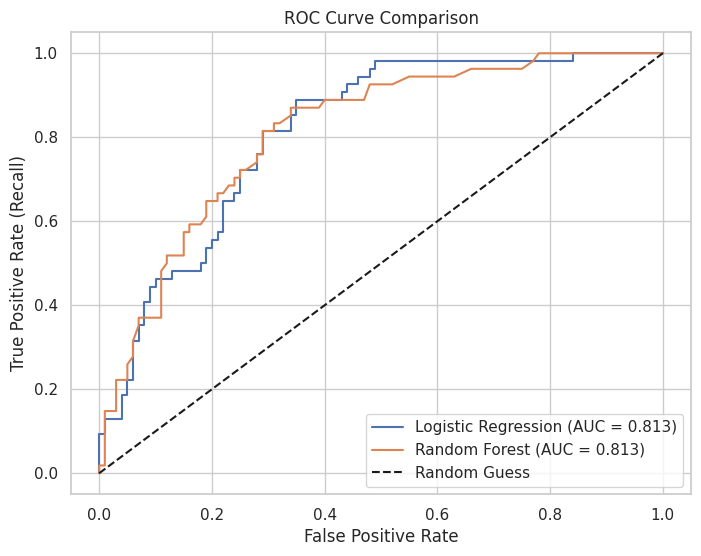

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [36]:
# PIPELINE + RANDOMIZED SEARCH 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import numpy as np
np.random.seed(42)

pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [None, 6, 10, 20],
    "model__min_samples_split": [2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(pipe_rf, param_distributions=param_dist,
                        n_iter=20, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=2, random_state=42)
rs.fit(X_train, y_train)

best_model = rs.best_estimator_
print("Best ROC AUC (CV):", rs.best_score_)
print("Best params:", rs.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best ROC AUC (CV): 0.8371483942414175
Best params: {'model__n_estimators': 100, 'model__min_samples_split': 4, 'model__max_features': 'sqrt', 'model__max_depth': 6}


In [37]:
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Predict probabilities (IMPORTANT: use probabilities, not labels)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

# Default threshold = 0.5
y_test_pred = (y_test_prob >= 0.5).astype(int)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_prob)
print("Test ROC-AUC:", round(roc_auc, 3))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["No Diabetes", "Diabetes"]
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)


Test ROC-AUC: 0.826

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.84      0.76      0.80       100
    Diabetes       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Confusion Matrix:
 [[76 24]
 [15 39]]


In [38]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score
import numpy as np

# Predicted probabilities for Diabetes (positive class)
y_prob = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.2, 0.55, 0.05)

print("Threshold | Recall (Diabetes)")
print("-" * 30)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recall = recall_score(y_test, y_pred_t)
    print(f"{t:8.2f} | {recall:.3f}")


Threshold | Recall (Diabetes)
------------------------------
    0.20 | 0.944
    0.25 | 0.926
    0.30 | 0.889
    0.35 | 0.870
    0.40 | 0.852
    0.45 | 0.796
    0.50 | 0.722


In [39]:
# Apply chosen threshold
threshold = 0.4
y_pred_04 = (y_prob >= threshold).astype(int)

print("Threshold =", threshold)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_04,
    target_names=["No Diabetes", "Diabetes"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_04))


Threshold = 0.4

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.89      0.67      0.77       100
    Diabetes       0.58      0.85      0.69        54

    accuracy                           0.73       154
   macro avg       0.74      0.76      0.73       154
weighted avg       0.78      0.73      0.74       154

Confusion Matrix:
[[67 33]
 [ 8 46]]


In [40]:
import joblib

artifact = {
    "model": best_model,
    "threshold": 0.4,
    "features": list(X.columns)
}

joblib.dump(artifact, "diabetes_rf_pipeline_v1.joblib")
print("Model saved successfully ✅")


Model saved successfully ✅
